In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))
import pandas as pd
import config
import firms_api


firms_api.check_map_key()

MAP_KEY is valid. Used 0/5000 transactions per 10 minutes.


{'transaction_limit': 5000,
 'current_transactions': 0,
 'transaction_interval': '10 minutes'}

In [2]:
availability=firms_api.get_data_availability()
availability

,data_id,min_date,max_date
0,MODIS_NRT,2026-05-01,2026-09-01
1,MODIS_SP,2000-11-01,2026-04-30
2,VIIRS_NOAA20_NRT,2026-06-01,2026-09-01
3,VIIRS_NOAA20_SP,2018-04-01,2026-05-31
4,VIIRS_NOAA21_NRT,2024-01-17,2026-09-01
5,VIIRS_SNPP_NRT,2026-04-28,2026-09-01
6,VIIRS_SNPP_SP,2012-01-20,2026-04-27
7,LANDSAT_NRT,2022-06-20,2026-08-31
8,GOES_NRT,2022-08-09,2026-09-01
9,BA_MODIS,2000-11-01,2026-05-01


In [3]:
print(f"Study period: {config.STUDY_START} to {config.STUDY_END}\n")

usable=firms_api.pick_sources_covering(config.STUDY_START,config.STUDY_END,availability)
usable

Study period: 2020-01-01 to 2025-12-31



,data_id,min_date,max_date
0,MODIS_SP,2000-11-01,2026-04-30
1,VIIRS_NOAA20_SP,2018-04-01,2026-05-31
2,VIIRS_SNPP_SP,2012-01-20,2026-04-27
3,BA_MODIS,2000-11-01,2026-05-01
4,BA_VIIRS,2012-03-01,2026-05-01


In [4]:
SAMPLE_BBOX=config.BBOX_CHIANG_MAI
SAMPLE_DATE="2025-03-15"
SAMPLE_DAYS=3

df=firms_api.download_firms(
    source=config.DEFAULT_SOURCE,
    bbox=SAMPLE_BBOX,
    day_range=SAMPLE_DAYS,
    date=SAMPLE_DATE
)
print("Rows and columns:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

[cache] Reading VIIRS_SNPP_SP_98_17_100_20_2025-03-15_3d.csv
Rows and columns: (1805, 15)
Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,17.04542,98.78677,351.19,0.43,0.38,2025-03-15,630,N,VIIRS,n,2,312.07,10.57,D,0
1,17.04822,98.78217,344.88,0.43,0.38,2025-03-15,630,N,VIIRS,n,2,309.46,4.92,D,0
2,17.05170,98.78164,342.99,0.43,0.38,2025-03-15,630,N,VIIRS,n,2,308.04,4.35,D,0
3,17.07812,98.50713,340.44,0.44,0.38,2025-03-15,630,N,VIIRS,n,2,311.13,3.24,D,0
4,17.08163,98.50656,336.56,0.44,0.38,2025-03-15,630,N,VIIRS,n,2,309.23,3.24,D,0


In [5]:
df_vn=firms_api.download_firms(
    source=config.DEFAULT_SOURCE,
    bbox=config.BBOX_TAY_NGUYEN,
    day_range=SAMPLE_DAYS,
    date=SAMPLE_DATE
)
print("Rows and columns:", df_vn.shape)
print("Columns:", df_vn.columns.tolist())
df_vn.head()

[cache] Reading VIIRS_SNPP_SP_107_11_109_14_2025-03-15_3d.csv
Rows and columns: (571, 15)
Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,11.06114,108.20975,341.70,0.42,0.45,2025-03-15,628,N,VIIRS,n,2,297.07,6.38,D,0
1,11.24616,108.60718,337.11,0.45,0.47,2025-03-15,628,N,VIIRS,n,2,300.88,5.44,D,0
2,11.24877,108.60622,355.00,0.45,0.47,2025-03-15,628,N,VIIRS,n,2,301.78,13.10,D,0
3,11.25041,108.60600,346.16,0.45,0.47,2025-03-15,628,N,VIIRS,n,2,299.90,5.44,D,0
4,11.46760,108.32860,343.76,0.44,0.46,2025-03-15,628,N,VIIRS,n,2,290.97,4.34,D,0


In [6]:
import data_utils

data_utils.describe_firms(df,name=f"{config.DEFAULT_SOURCE} - northern Thailand, {SAMPLE_DATE} +{SAMPLE_DAYS}d")

OVERVIEW: VIIRS_SNPP_SP - northern Thailand, 2025-03-15 +3d

[1] Shape: 1805 rows x 15 columns

[2] Column data types:
latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64

[3] Missing values per column:
    None.

[4] Categorical columns:

  confidence  (object)
    confidence
    n    1625
    l     154
    h      26

  satellite  (object)
    satellite
    N    1805

  instrument  (object)
    instrument
    VIIRS    1805

  daynight  (object)
    daynight
    N    1198
    D     607

  version  (int64)
    version
    2    1805

  type  (int64)
    type
    0    1805

[5] Numeric columns:
       bright_ti4  bright_ti5      frp     scan    track
count     1805.00     1805.00  1805.00  1805.00  1805.00
mean     

In [7]:
df=data_utils.add_datetime_columns(df)
df[["acq_date", "acq_time", "acq_datetime_utc", "acq_datetime_local", "hour_local"]].head(10)

,acq_date,acq_time,acq_datetime_utc,acq_datetime_local,hour_local
0,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
1,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
2,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
3,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
4,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
5,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
6,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
7,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
8,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13
9,2025-03-15,630,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,13


In [8]:
data_utils.count_date_shifts(df)

Records that change calendar day when converted to local time: 1198/1805 (66.4%)


1198

hour_local
1     544
2     646
3       8
12     82
13    466
14     59


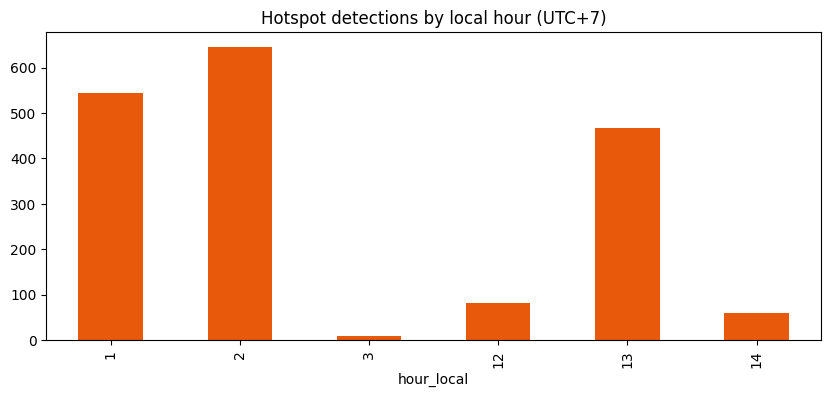

In [9]:
# Which local hour produces the most detections?
by_hour = df["hour_local"].value_counts().sort_index()
print(by_hour.to_string())

by_hour.plot(
    kind="bar", figsize=(10, 4), color="#E8590C",
    title="Hotspot detections by local hour (UTC+7)",
);

In [10]:
df_modis=firms_api.download_firms(config.COMPARE_SOURCE,SAMPLE_BBOX,day_range=1,date=SAMPLE_DATE)
df_viirs=firms_api.download_firms(config.DEFAULT_SOURCE,SAMPLE_BBOX,day_range=1,date=SAMPLE_DATE)

data_utils.compare_sensors(df_modis,df_viirs)

[cache] Reading MODIS_SP_98_17_100_20_2025-03-15_1d.csv
[cache] Reading VIIRS_SNPP_SP_98_17_100_20_2025-03-15_1d.csv


Sensor,MODIS,VIIRS
Hotspot count,77.000,986.000
Median FRP (MW),10.800,1.610
Max FRP (MW),751.600,29.110
Mean brightness (K),323.520,NaN
Mean pixel area (km2),1.328,0.144
Mean bright_ti4 (K),NaN,320.610


In [11]:
df_clean=data_utils.filter_hotspots(df,min_confidence="n",vegetation_only=True)
df_clean.head()

Before filtering: 1805 -> after: 1651 (91.5% retained)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,bright_ti5,frp,daynight,type,acq_datetime_utc,acq_datetime_local,acq_date_local,year,month,hour_local
0,17.04542,98.78677,351.19,0.43,0.38,2025-03-15,630,N,VIIRS,n,...,312.07,10.57,D,0,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,2025-03-15,2025,3,13
1,17.04822,98.78217,344.88,0.43,0.38,2025-03-15,630,N,VIIRS,n,...,309.46,4.92,D,0,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,2025-03-15,2025,3,13
2,17.05170,98.78164,342.99,0.43,0.38,2025-03-15,630,N,VIIRS,n,...,308.04,4.35,D,0,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,2025-03-15,2025,3,13
3,17.07812,98.50713,340.44,0.44,0.38,2025-03-15,630,N,VIIRS,n,...,311.13,3.24,D,0,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,2025-03-15,2025,3,13
4,17.08163,98.50656,336.56,0.44,0.38,2025-03-15,630,N,VIIRS,n,...,309.23,3.24,D,0,2025-03-15 06:30:00+00:00,2025-03-15 13:30:00+00:00,2025-03-15,2025,3,13


Saved figure: D:\Duanduhoche.Huy\wildfire-risk-analysis\figures\hotspot_scatter.png


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'VIIRS detections, northern Thailand, 2025-03-15 +3d (filtered)'}, xlabel='Longitude', ylabel='Latitude'>)

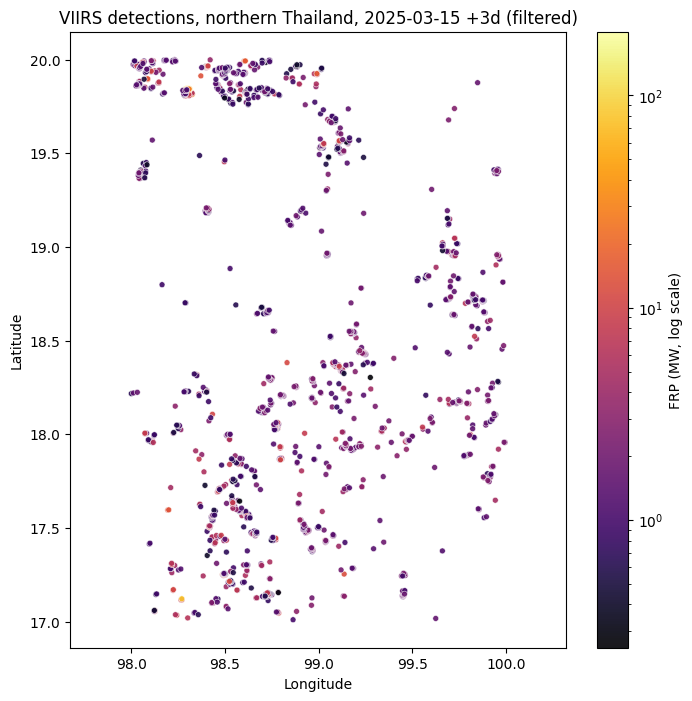

In [12]:
data_utils.plot_hotspots(
    df_clean,
    title=f"VIIRS detections, northern Thailand, {SAMPLE_DATE} +{SAMPLE_DAYS}d (filtered)",
    out_path=config.FIGURES_DIR / "hotspot_scatter.png"
)